In [1]:
import torch
from sklearn import datasets, model_selection
from sklearn.linear_model import RidgeCV
from torch.utils.data import DataLoader, Dataset
from xgboost import XGBClassifier

from muppet.benchmark.models.classifier import Classifier
from muppet.benchmark.plot_explanation import plot_explanation_tabular
from muppet.explainers import ShapTabularExplainer

In [2]:
# Load a dataset
iris = datasets.load_iris()

In [3]:
# Split train/test dataset
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    iris["data"],
    iris["target"],
    test_size=0.1,
    random_state=167,
    stratify=iris["target"],
)

In [4]:
class CustomDataset(Dataset):
    """Custom dataset class for SHAP explainer.

    A mock dataset implementation that provides test data
    for evaluating SHAP explainer functionality.
    """

    def __init__(self, features, labels):
        """Initializes the dataset with the given data.

        Args:
            features (np.ndarray): A NumPy array containing the features data.
            labels (np.ndarray): A NumPy array containing the labels data.
        """
        assert len(features) == len(labels)
        self.features = features
        self.labels = labels

    def __len__(self):
        """Returns the total number of samples in the dataset."""
        return len(self.features)

    def __getitem__(self, idx):
        """Retrieves a sample from the dataset at the specified index.

        Args:
            idx (int): The index of the sample to retrieve.

        Returns:
            tuple[np.ndarray, np.ndarray]
        """
        return self.features[idx], self.labels[idx]

In [5]:
# Use XGboost model and train
xgboost_model = XGBClassifier(
    objective="multi:softprob", eval_metric="mlogloss"
)
xgboost_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [6]:
# Convert to compatible torch-based model that can be inferred using the `predict_proba_func` method from xgboost model
torch_model = Classifier(
    model=xgboost_model,
    name="xgboost",
    pretrained=True,
    predict_proba_func="predict_proba",
)
torch_model.eval()

Classifier()

In [7]:
train_dataset = CustomDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32)

In [8]:
# initiate Shap explainer
shap_explainer = ShapTabularExplainer(
    model=torch_model,
    train_loader=train_loader,
    surrogate_model=RidgeCV(),
    # train_data=torch.tensor(X_train, dtype=torch.float32),
)

In [9]:
# Explain the model using shap method on one example in test set
k = 11
explanation_shap = shap_explainer(
    example=torch.tensor(X_test[k : k + 1], dtype=torch.float32)
)

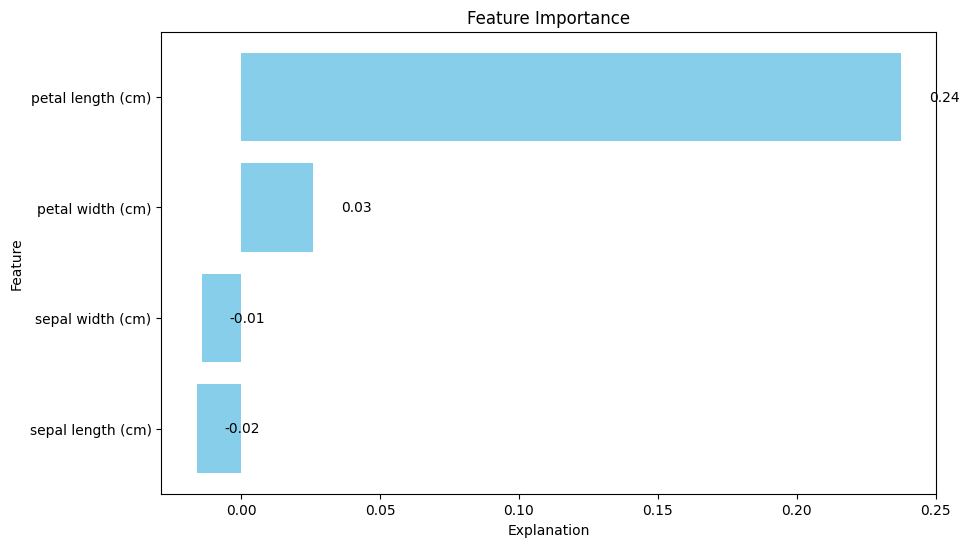

In [10]:
# Plot feature importance
plot_explanation_tabular(
    explanation=explanation_shap,
    feature_names=iris["feature_names"],
)